In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import seaborn as sns

In [2]:
df = pd.read_pickle('../data/03_df_data')

In [3]:
df.head(2)

,loan_type,loan_purpose,preapproval,construction_method,loan_amount,action_taken,state_code,county_code,census_tract,applicant_ethnicity_1,...,loan_term,intro_rate_period,balloon_payment,interest_only_payment,property_value,manufactured_home_secured_property_type,manufactured_home_land_property_interest,reg_uw,denied,reg_price
1,Conventional,Home purchase,Not requested,Site built,1205000,Purchased,WA,53033.0,53033032318.0,Not Hispanic Latino,...,360.0,NaN,No balloon,Not interest only,1505000.0,Not applicable,Not applicable,0,0,0
2,Conventional,Home purchase,Not requested,Site built,925000,Purchased,WA,53011.0,53011040303.0,Info not provided,...,360.0,NaN,No balloon,Not interest only,1035000.0,Not applicable,Not applicable,0,0,0


In [4]:
reg_sum_race = pd.read_pickle('../data/04_df_reg_applicant_race_1.pkl')
reg_sum_sex = pd.read_pickle('../data/04_df_reg_applicant_sex.pkl')
reg_sum_age = pd.read_pickle('../data/04_df_reg_applicant_age_above_62.pkl')

reg_summary = pd.concat([reg_sum_race,reg_sum_sex],axis=0)

reg_summary = pd.concat([reg_summary,reg_sum_age],axis=0)


reg_summary['seg'] = reg_summary['loan type'] + '-' + reg_summary['loan purpose']

reg_summary.shape



(234, 8)

In [5]:
reg_summary.head()

,loan type,loan purpose,step,model,protected basis,metric,value,seg
0,Conventional,Cash out refinance,uw,Model 0,Black African American,param,0.08468,Conventional-Cash out refinance
1,Conventional,Cash out refinance,uw,Model 0,Black African American,pval,0.306813,Conventional-Cash out refinance
2,Conventional,Cash out refinance,uw,Model 0,Black African American,psu R2,0.000148,Conventional-Cash out refinance
3,Conventional,Cash out refinance,uw,Model 1,Black African American,param,0.153658,Conventional-Cash out refinance
4,Conventional,Cash out refinance,uw,Model 1,Black African American,pval,0.133076,Conventional-Cash out refinance


In [6]:
def pie_plot(df,var):
    counts = df.groupby(f'{var}').size()

    fig, ax = plt.subplots(figsize=(6,6), facecolor="white")
    ax.set_facecolor("white")

    ax.pie(
        counts.values,
        labels=counts.index.astype(str),
        autopct="%1.1f%%",
        startangle=90
    )

    ax.axis("equal")
    plt.show()
    

In [7]:
def plot_reg(
    regs_summary, # reg summary dataframe
    purp, #segment
    step, # uw or price
    metric, # param, pval, r2
):
    
    regs_ = reg_summary[
        (reg_summary.step == f'{step}') & 
        (reg_summary.metric == f'{metric}') &
        (reg_summary['loan purpose'] == f'{purp}')
        ]#.copy()

    print(regs_.shape)

    regs_["value"] = regs_["value"].astype(float)

    if metric == 'param':
        regs_['value'] = np.exp(regs_['value'])
    
    # Create a pivot table
    # pivot = regs_.pivot_table(
    #     index=["loan type", "model"],
    #     columns="protected basis",
    #     values="value",
    #     aggfunc="sum"
    # )


    pivot = regs_.pivot_table(
    index=["loan type", "protected basis"],
    columns="model",
    values="value",
    aggfunc="sum"
    )

    # Plot the pivot table
    ax = pivot.plot(kind="bar", figsize=(10, 5), width=0.8)

    # Create readable labels from the MultiIndex
    labels = [
        f"{a}\n{b}"
        for a, b in pivot.index
        ]

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=0, ha="center")

    ax.set_xlabel("Test")
    ax.set_ylabel('value')
    ax.set_title(f"{metric}")

    plt.tight_layout()
    plt.xticks(rotation=90)
    plt.show()   

# underwriting

## effect

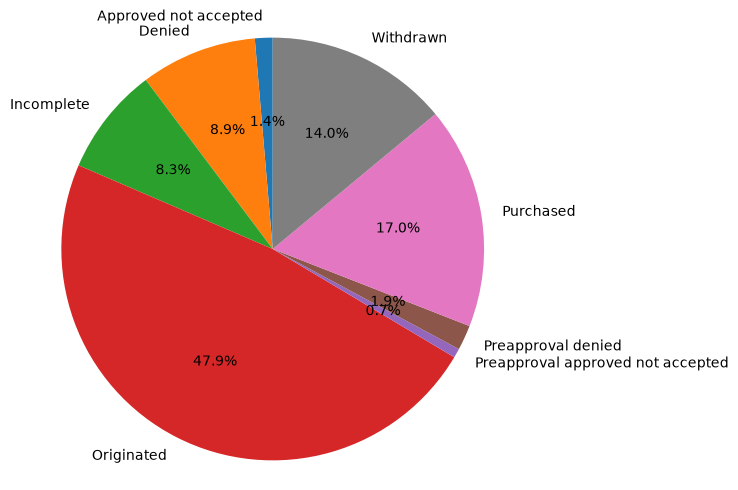

In [8]:
pie_plot(df,'action_taken')

Cash out refinance
(12, 8)


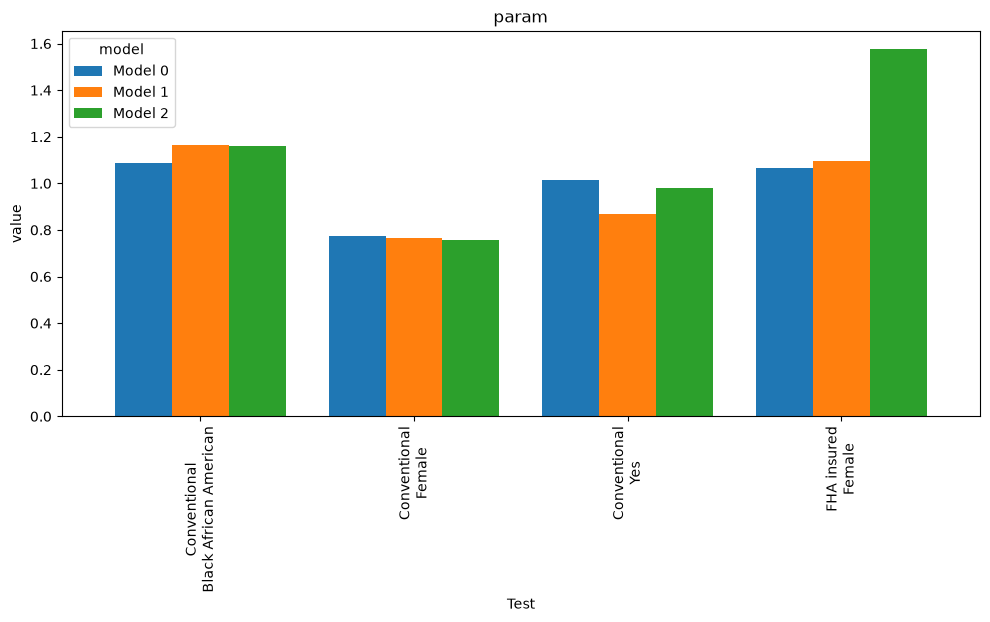

Home purchase
(15, 8)


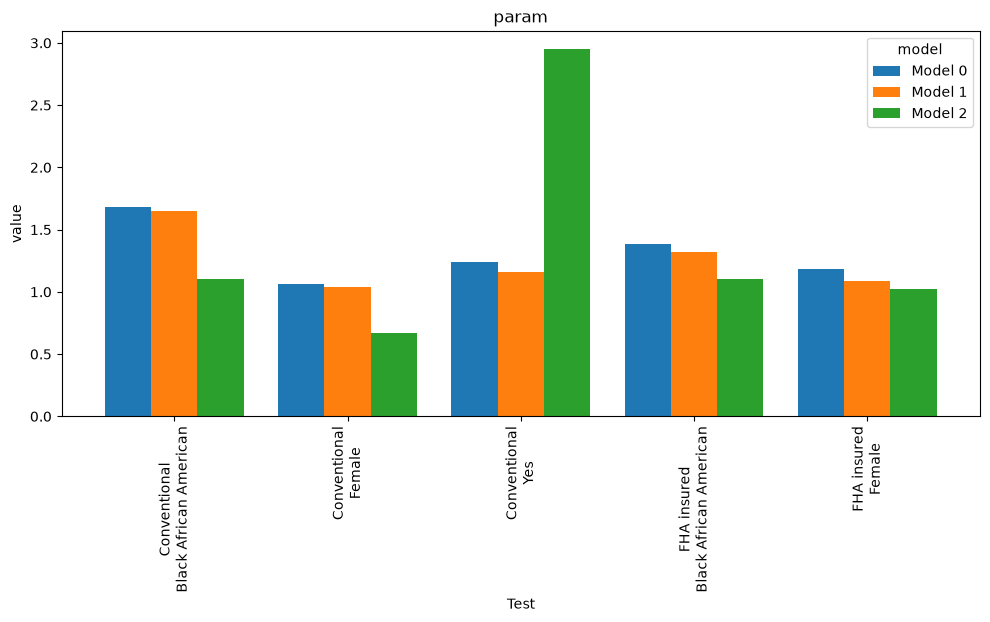

Home improvement
(6, 8)


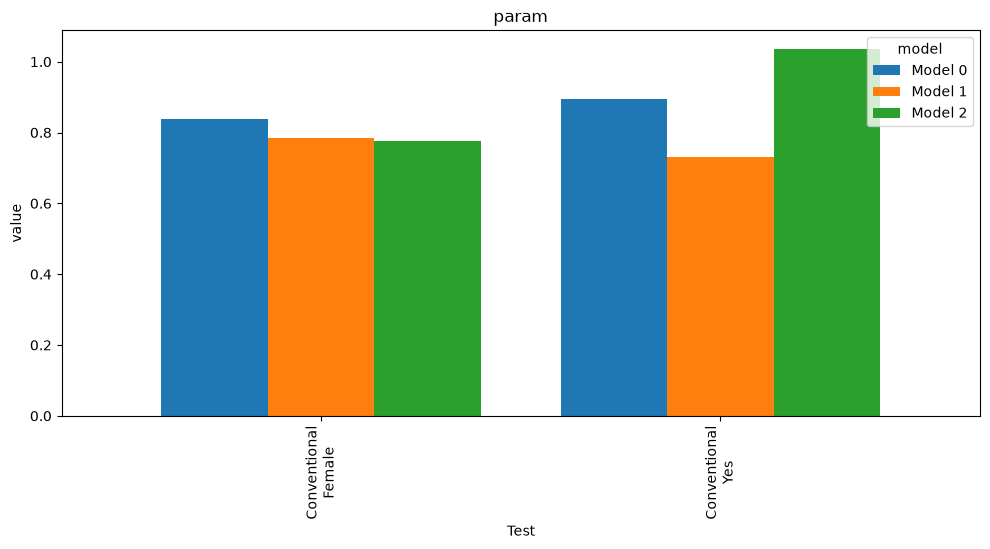

Refinance
(6, 8)


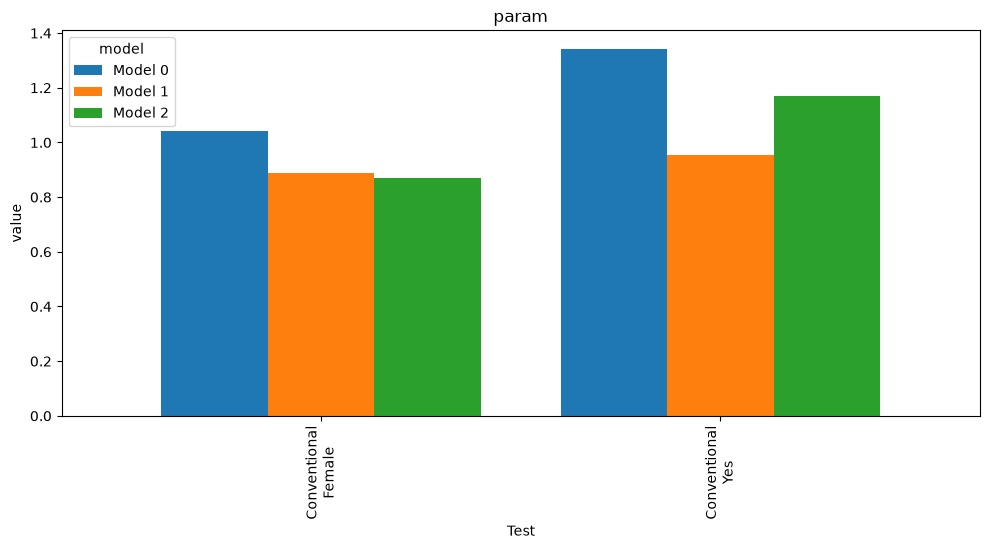

In [9]:
for i in reg_summary['loan purpose'].unique().tolist():
    print(i)
    
    plot_reg(reg_summary,i, 'uw', 'param')


    # break

## significance

Cash out refinance
(12, 8)


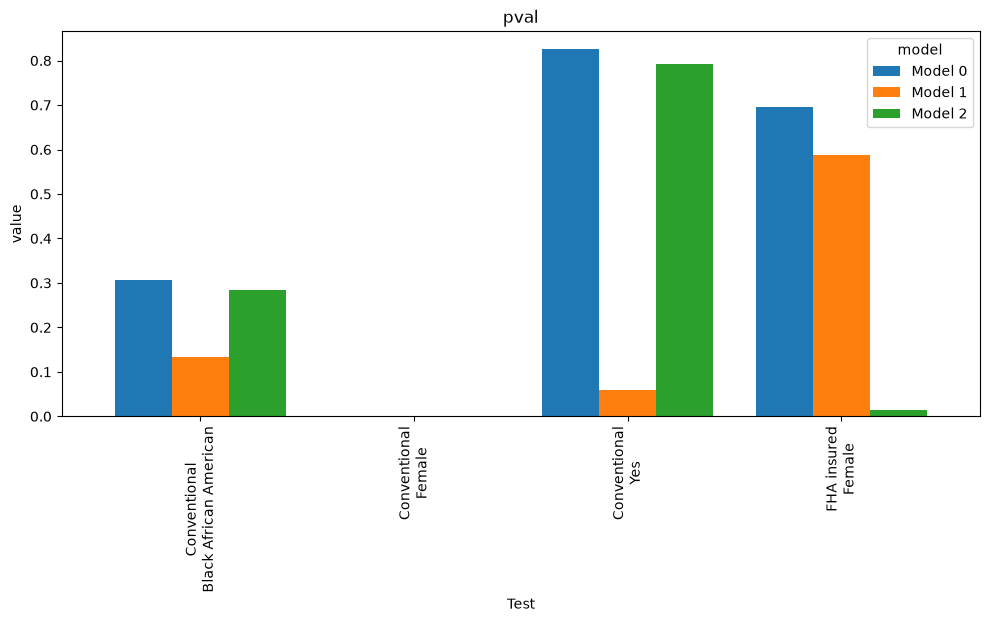

Home purchase
(15, 8)


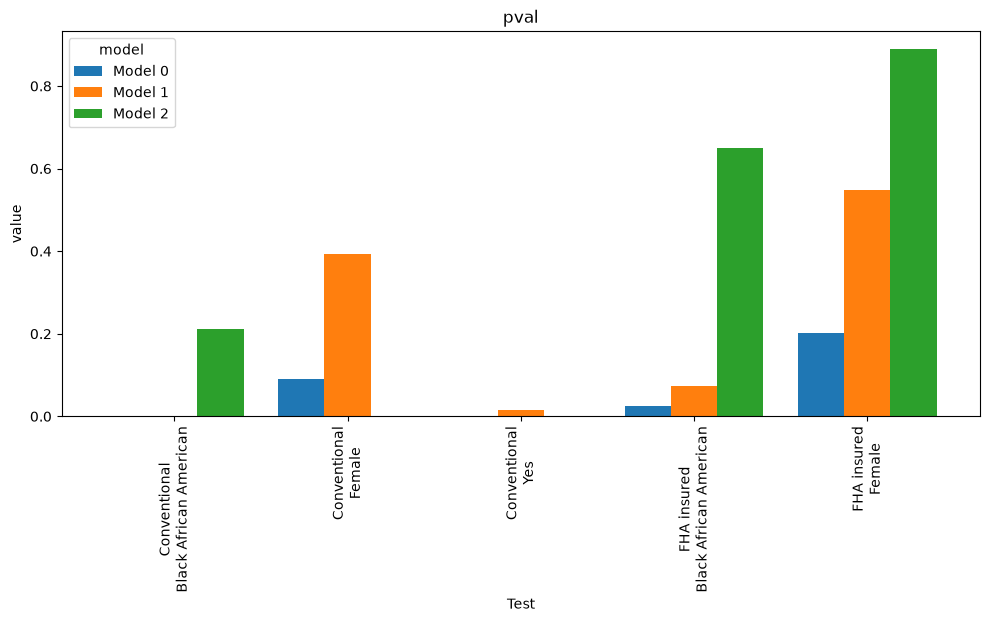

Home improvement
(6, 8)


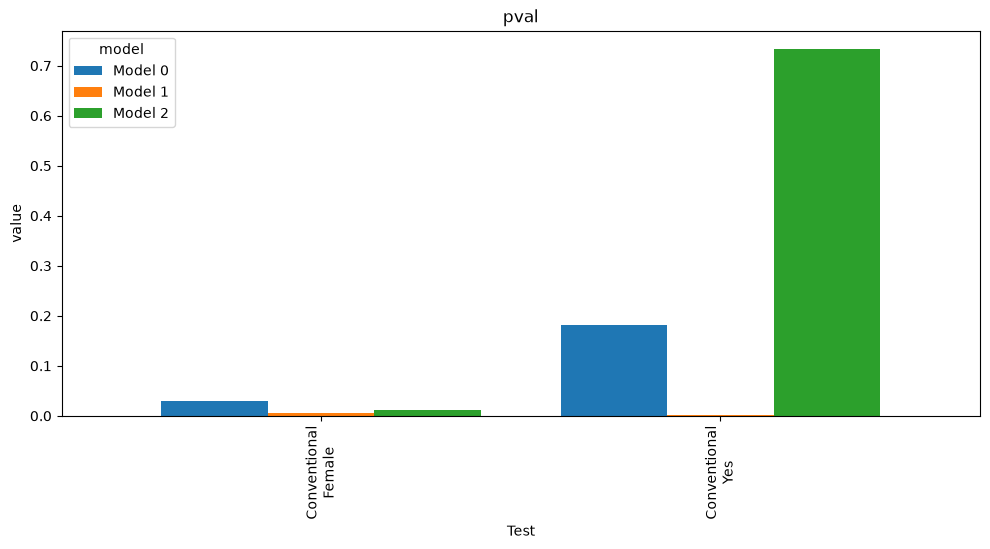

Refinance
(6, 8)


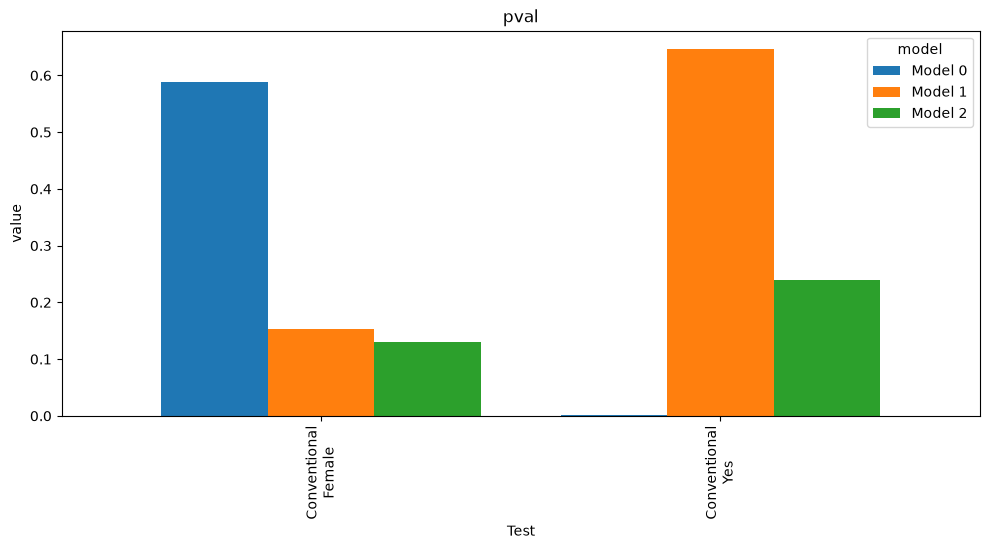

In [10]:
# plot_reg(reg_summary, 'uw', 'pval')
for i in reg_summary['loan purpose'].unique().tolist():
    print(i)
    
    plot_reg(reg_summary,i, 'uw', 'pval')


    # break

## model fit

Cash out refinance
(12, 8)


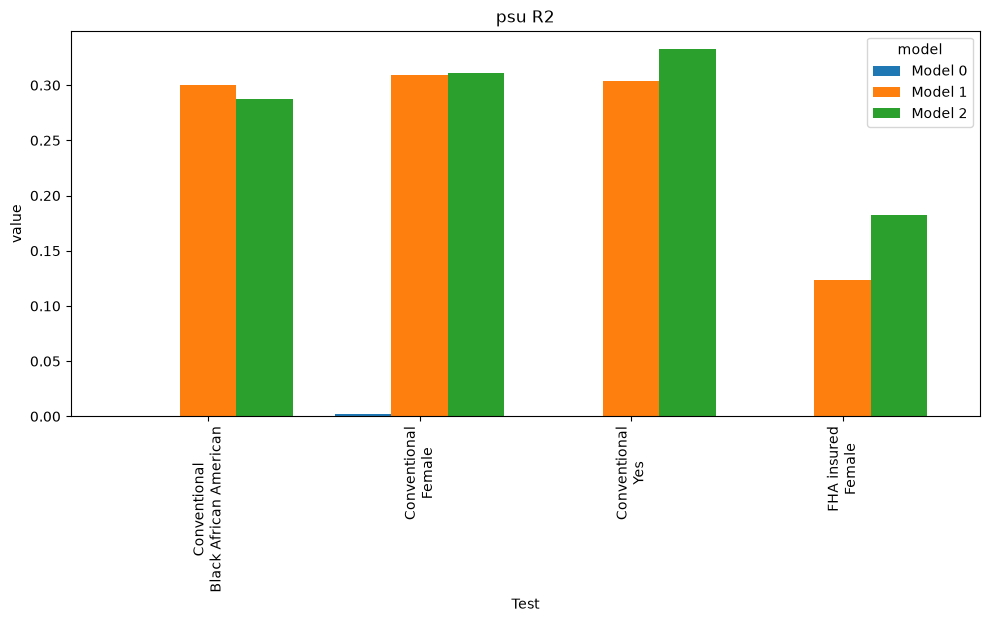

Home purchase
(15, 8)


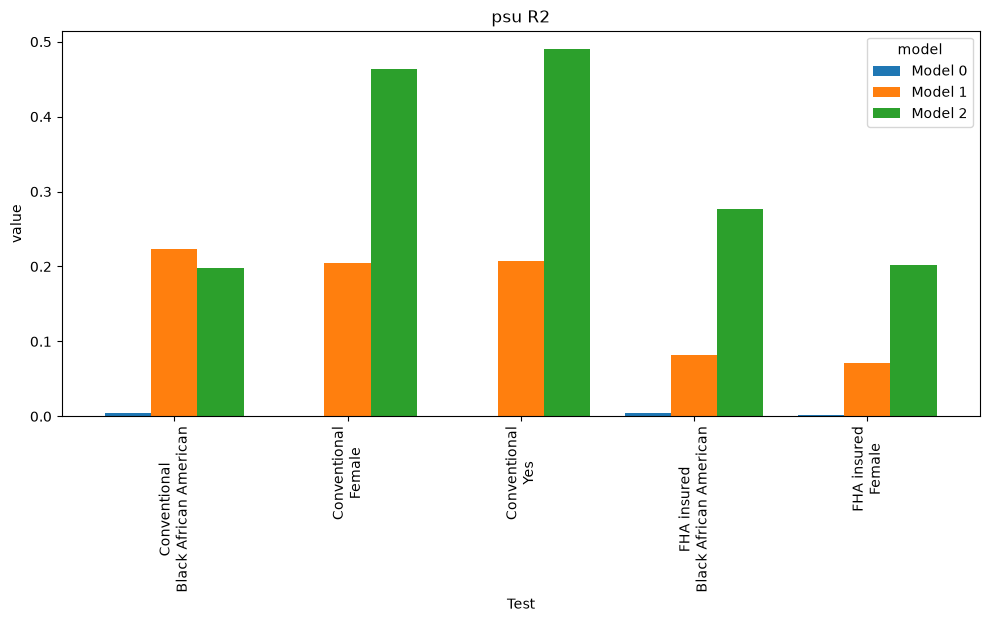

Home improvement
(6, 8)


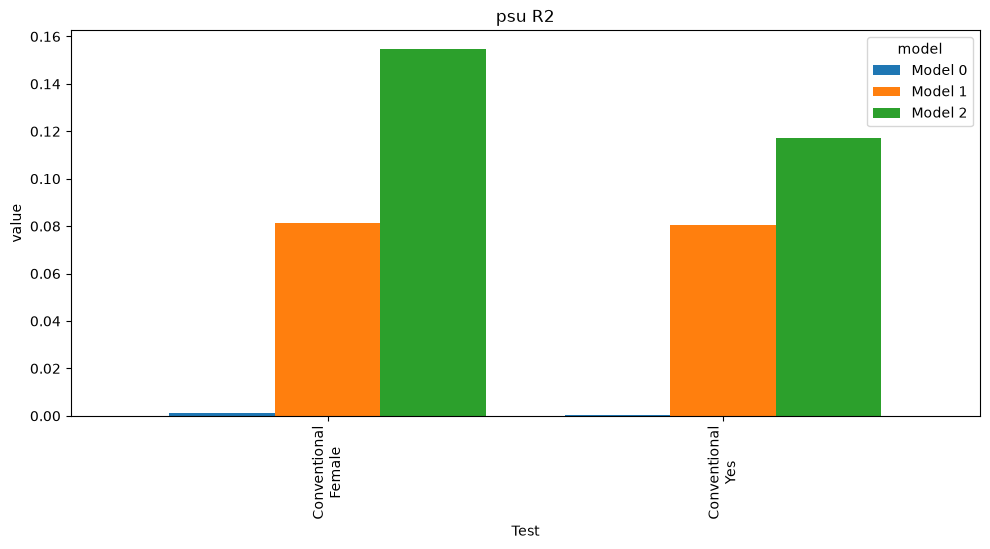

Refinance
(6, 8)


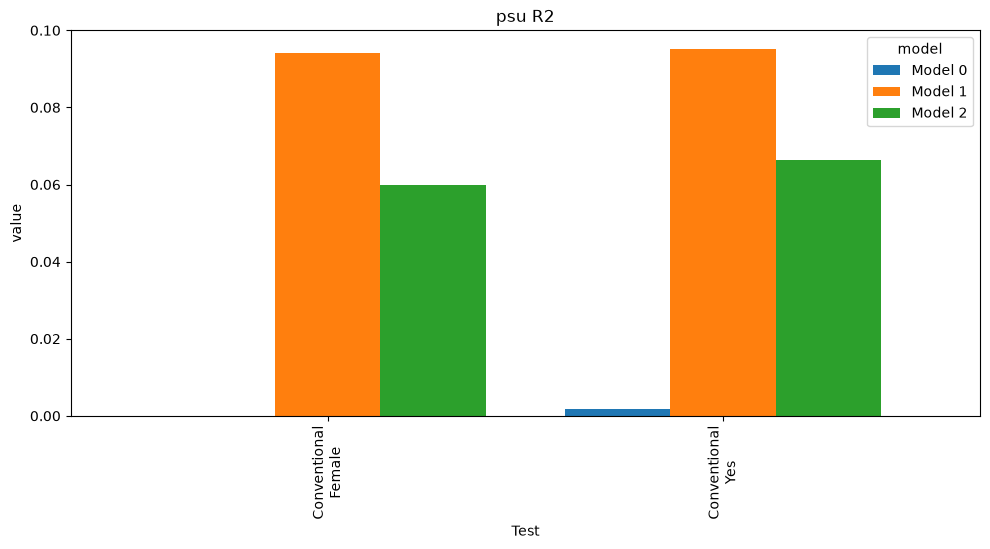

In [11]:
# plot_reg(reg_summary, 'uw', 'psu R2')

for i in reg_summary['loan purpose'].unique().tolist():
    print(i)
    
    plot_reg(reg_summary,i, 'uw', 'psu R2')


    # break

# pricing

## descriptive

In [12]:
df = df[df.reg_price == 1]

## effect

<Axes: >

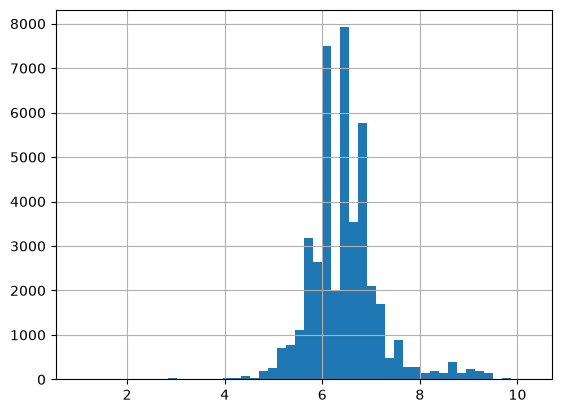

In [13]:
df[df.interest_rate != -9999].interest_rate.hist(bins = 50)

Cash out refinance
(12, 8)


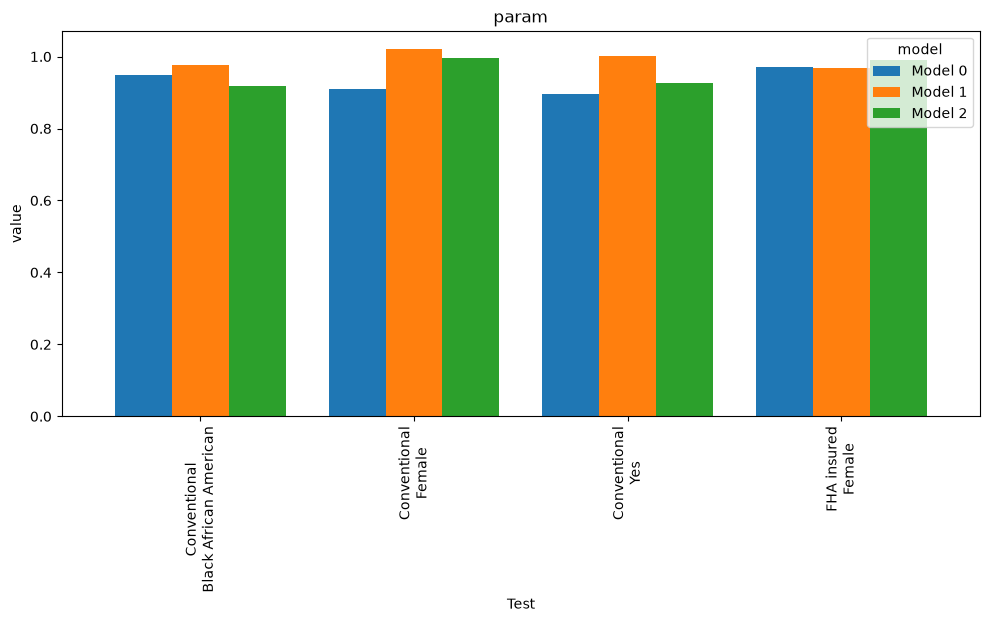

Home purchase
(15, 8)


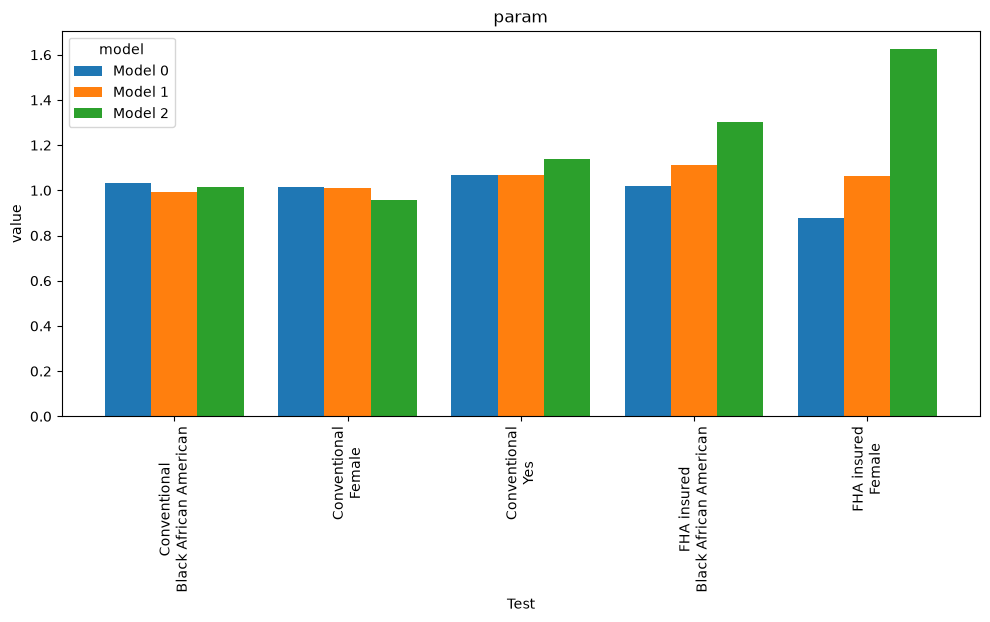

Home improvement
(6, 8)


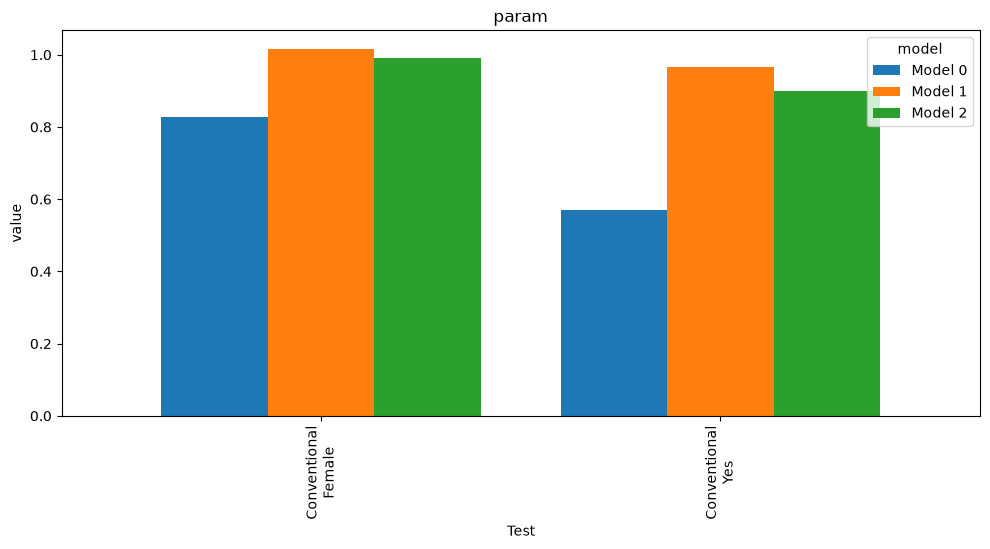

Refinance
(6, 8)


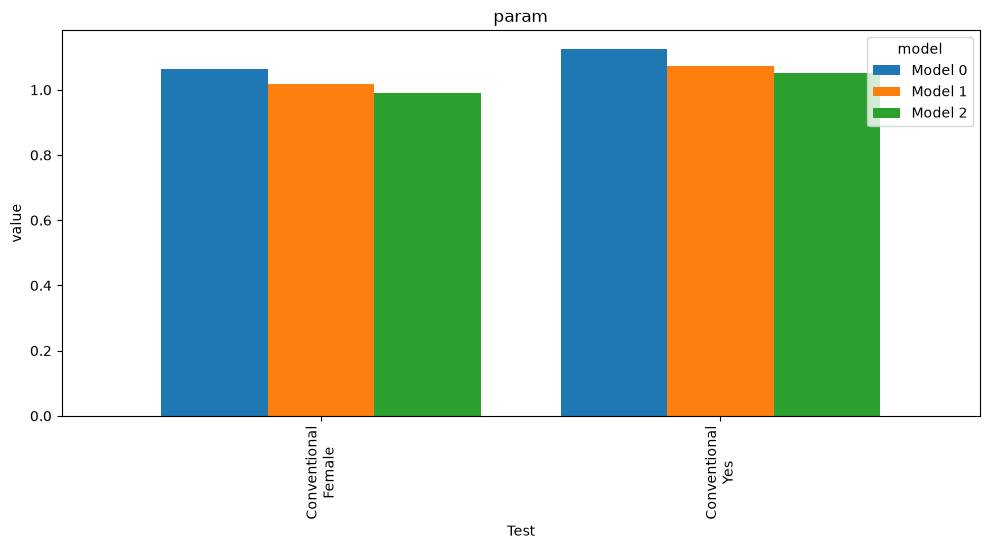

In [14]:
for i in reg_summary['loan purpose'].unique().tolist():
    print(i)
    
    plot_reg(reg_summary,i, 'price', 'param')


    # break

## significance

Cash out refinance
(12, 8)


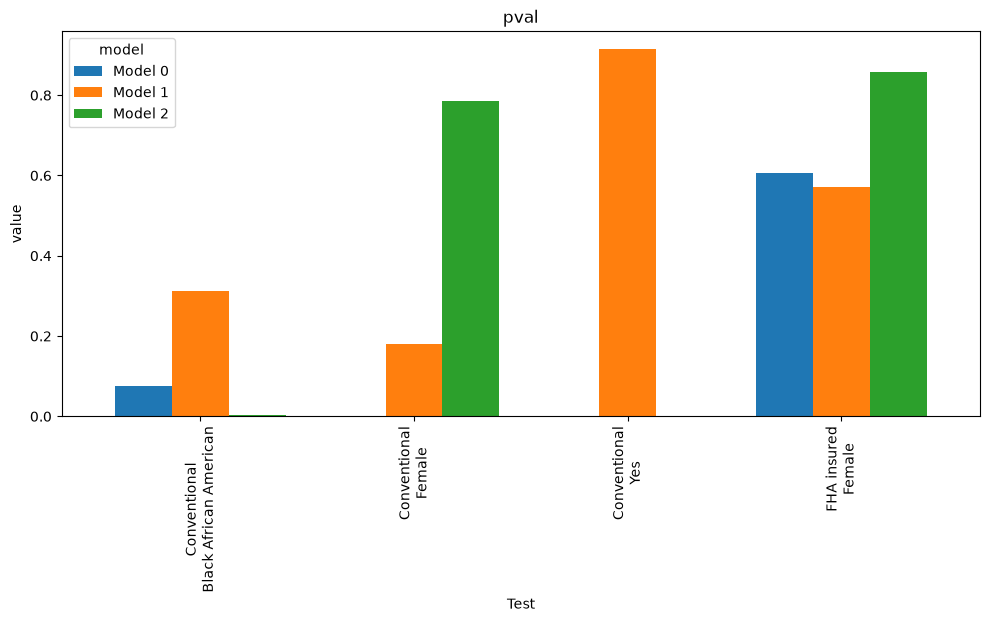

Home purchase
(15, 8)


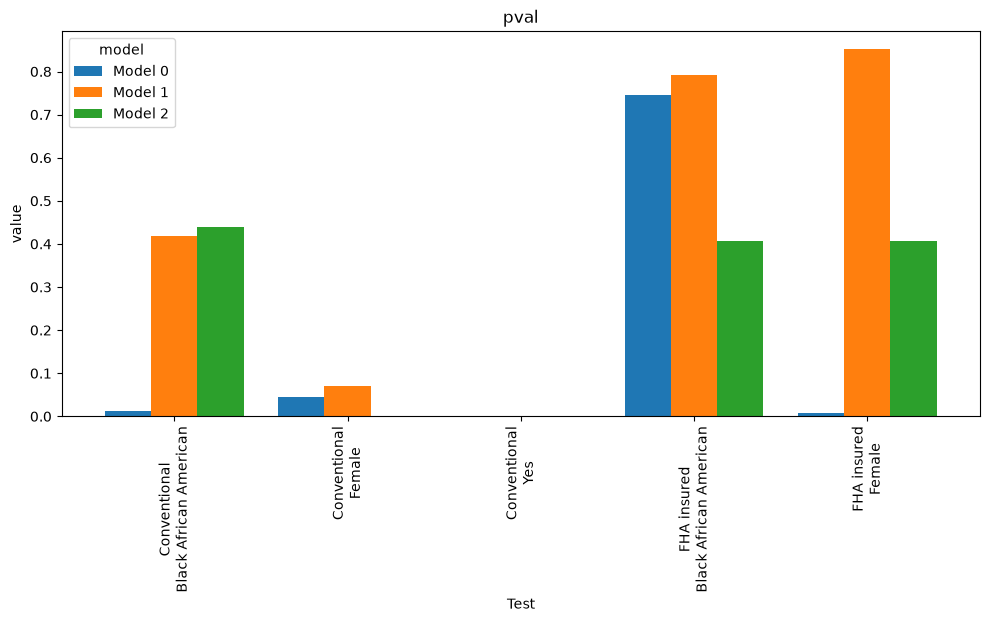

Home improvement
(6, 8)


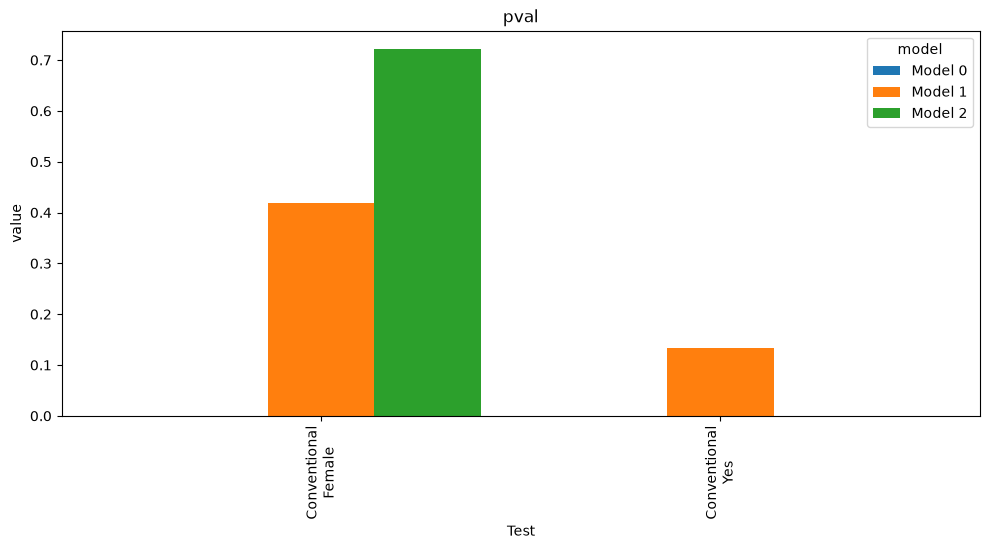

Refinance
(6, 8)


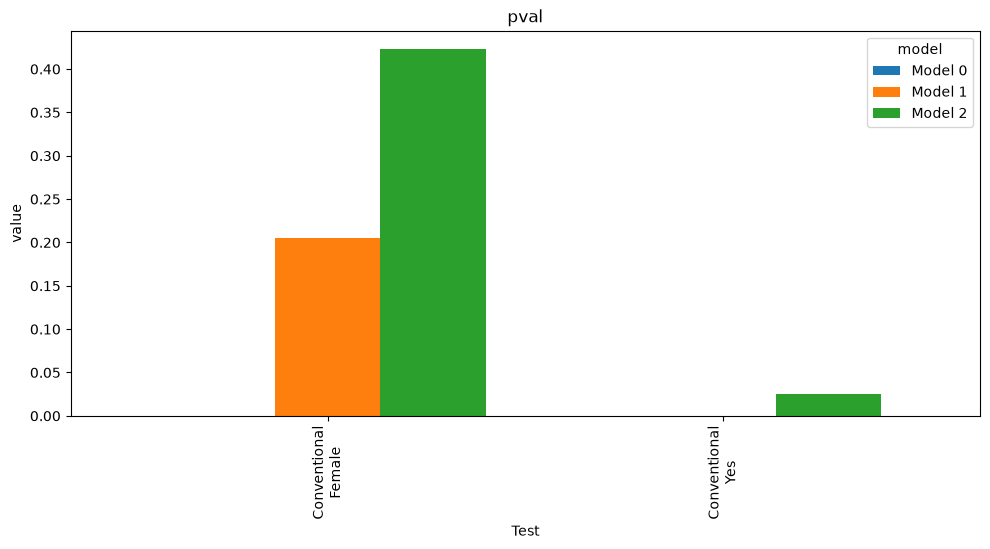

In [15]:
# plot_reg(reg_summary, 'uw', 'pval')
for i in reg_summary['loan purpose'].unique().tolist():
    print(i)
    
    plot_reg(reg_summary,i, 'price', 'pval')


    # break

## model fit

Cash out refinance
(12, 8)


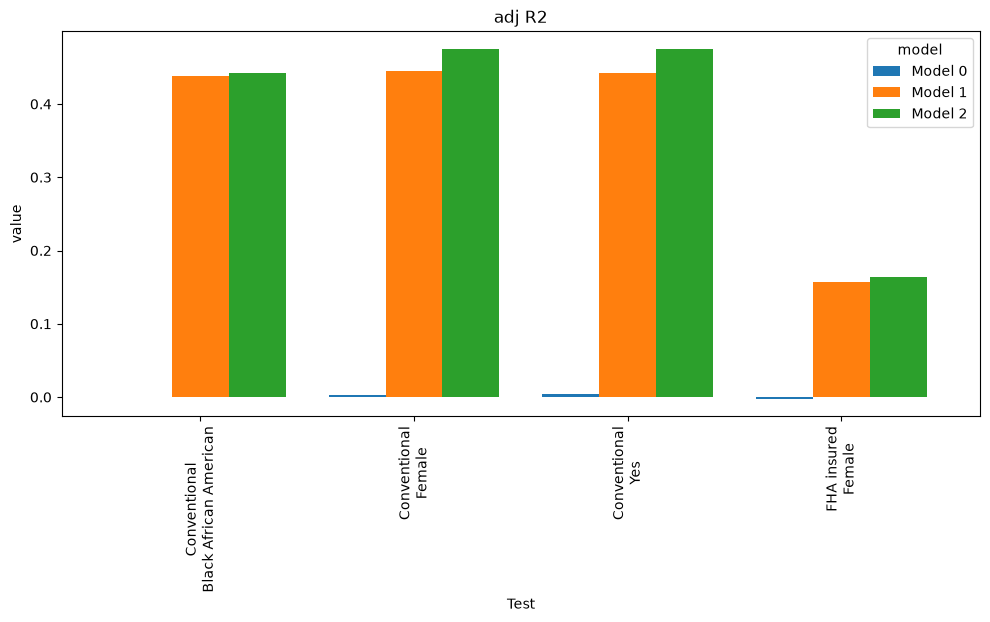

Home purchase
(15, 8)


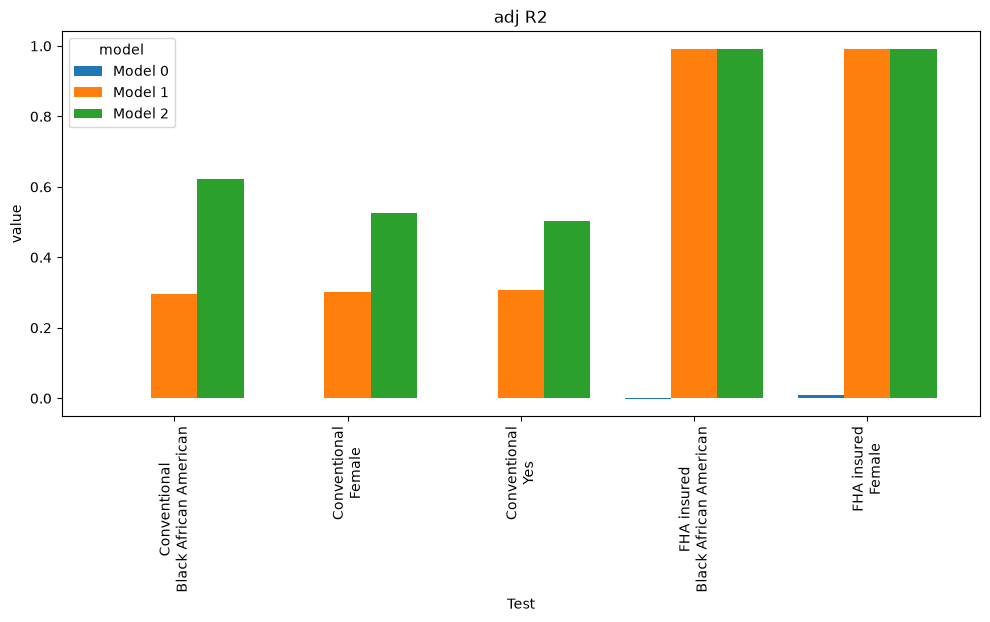

Home improvement
(6, 8)


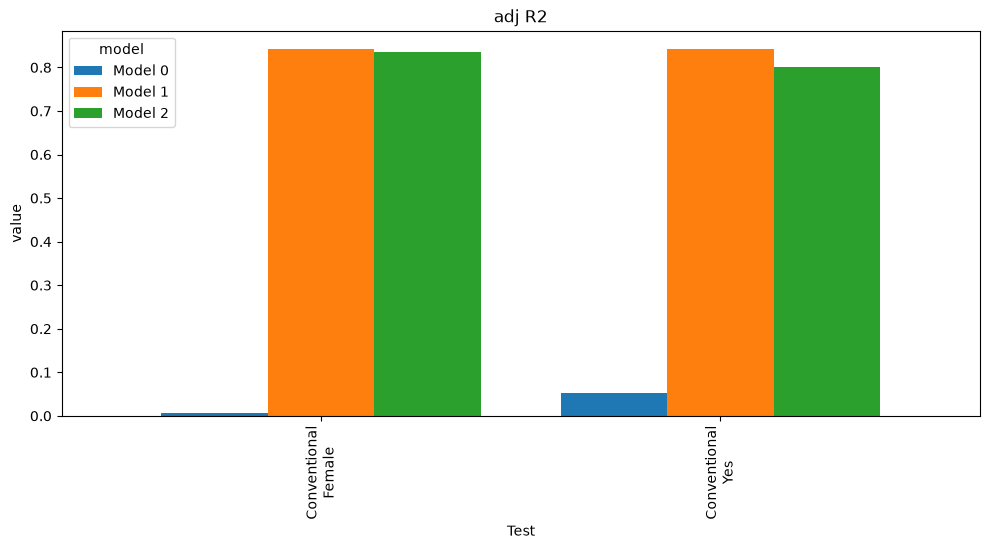

Refinance
(6, 8)


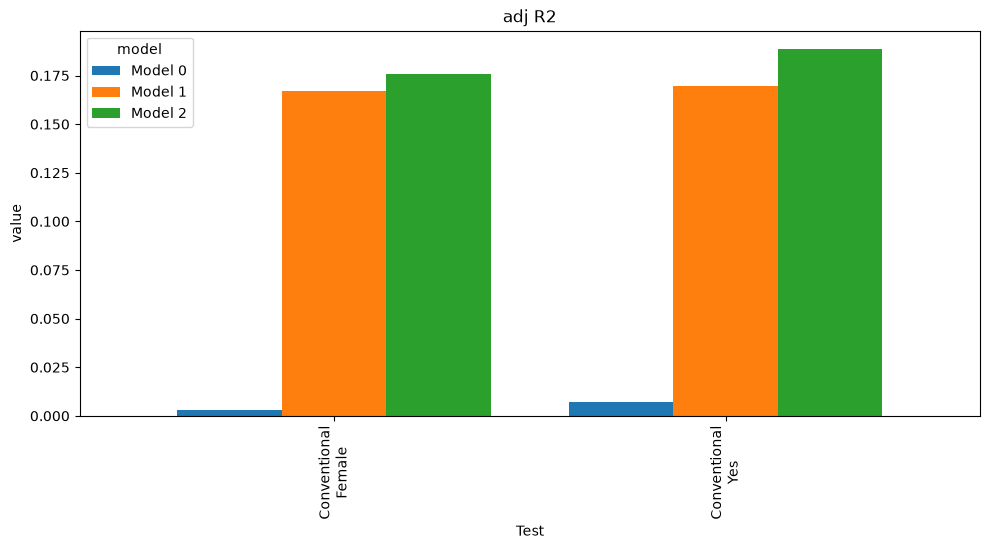

In [16]:
# plot_reg(reg_summary, 'uw', 'psu R2')

for i in reg_summary['loan purpose'].unique().tolist():
    print(i)
    
    plot_reg(reg_summary,i, 'price', 'adj R2')


    # break